<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/alex/RA1_TP5/EJERCICIO_2/RA1_Trabajo_pr%C3%A1ctico_N%C2%B0_5_G8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2: Clasificación de especies de Iris



**Inteligencia Computacional · IC415 · Año 2026**

---

## Contexto

Un jardín botánico nacional dispone de 150 registros morfológicos (largo y ancho de sépalo y pétalo) de tres especies del género *Iris*: *setosa*, *versicolor* y *virginica*. Se quiere un sistema automático de identificación de especie a partir de esas cuatro mediciones, y se necesita decidir si una red neuronal es la herramienta adecuada o si un clasificador más simple alcanza los mismos resultados con menor complejidad.

## Lo que condiciona el problema

**150 muestras, 50 por clase.** Con un split 80/20 estratificado quedan 120 muestras de entrenamiento y 30 de test (10 por clase). Un único error de clasificación en test mueve la accuracy 1/30 ≈ 3.3%. Esto significa que la varianza entre ejecuciones es alta y que comparar dos modelos por décimas de accuracy carece de significancia estadística. Se lo trata explícitamente en la sección de estabilidad entre semillas.

## Estructura

1. Setup y reproducibilidad.
2. Análisis Exploratorio (EDA).
3. Preprocesamiento y pipeline.
4. Modelado con RNA: arquitectura, experimentos de activación y tamaño, modelo final.
5. Evaluación de la RNA y estabilidad entre semillas.
6. Comparación con modelos clásicos.
7. Fronteras de decisión.
8. Curva de aprendizaje.
9. Decisión de ingeniería.



## 1. Setup y reproducibilidad

Fijamos semillas para `random`, `numpy`, `tensorflow`, la variable `PYTHONHASHSEED` y activamos `enable_op_determinism()` cuando está disponible. Sin todo esto, dos ejecuciones consecutivas dan métricas distintas y la comparación entre experimentos pierde validez.


In [1]:
# Fijación de semillas ANTES de cualquier import que las use.
import os
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

import random
import numpy as np
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
tf.random.set_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

def fijar_semillas(seed):
    """Helper para re-fijar todas las semillas; se usa en estabilidad entre semillas."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Semilla global: {SEED}")


TensorFlow: 2.20.0
NumPy: 2.0.2
Semilla global: 42


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn import datasets
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.3f}'.format)


## 2. Análisis Exploratorio (EDA)

Verificamos la estructura del dataset (tipos, nulos, balance), la escala relativa de las features, y la separabilidad geométrica entre clases. Cada hallazgo condiciona una decisión concreta del pipeline posterior.


In [3]:
iris = datasets.load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

print("Forma del dataset:", df.shape)
df.head()


Forma del dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.100,3.500,1.400,0.200,0,setosa
1,4.900,3.000,1.400,0.200,0,setosa
2,4.700,3.200,1.300,0.200,0,setosa
3,4.600,3.100,1.500,0.200,0,setosa
4,5.000,3.600,1.400,0.200,0,setosa


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [5]:
df.drop(columns=['target']).describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


150 filas, 4 features numéricas y un target categórico de 3 clases. Sin nulos, sin tipos mixtos: no hace falta imputación ni casting.

Las escalas son heterogéneas: `petal length` va de 1.0 a 6.9 cm con desvío ~1.77, mientras que `sepal width` va de 2.0 a 4.4 con desvío ~0.44. Esa diferencia de un orden de magnitud en varianza obliga a estandarizar antes de entrenar una RNA: si no, la feature de mayor varianza domina el gradiente y la red converge mucho más lento. Lo aplicamos en la sección 3.


In [6]:
conteo = df['species'].value_counts().sort_index()
print(conteo)
print("\nProporción:")
print((conteo / len(df) * 100).round(1).astype(str) + ' %')


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Proporción:
species
setosa        33.3 %
versicolor    33.3 %
virginica     33.3 %
Name: count, dtype: object


Balanceo perfecto (33.3% por clase). Accuracy es una métrica honesta en este escenario: no hay clase mayoritaria que infle la métrica con predicciones triviales. No corresponde aplicar `class_weight`, oversampling ni umbrales especiales. La estratificación en el split es trivial: cada clase aporta exactamente 10 muestras al test 80/20.


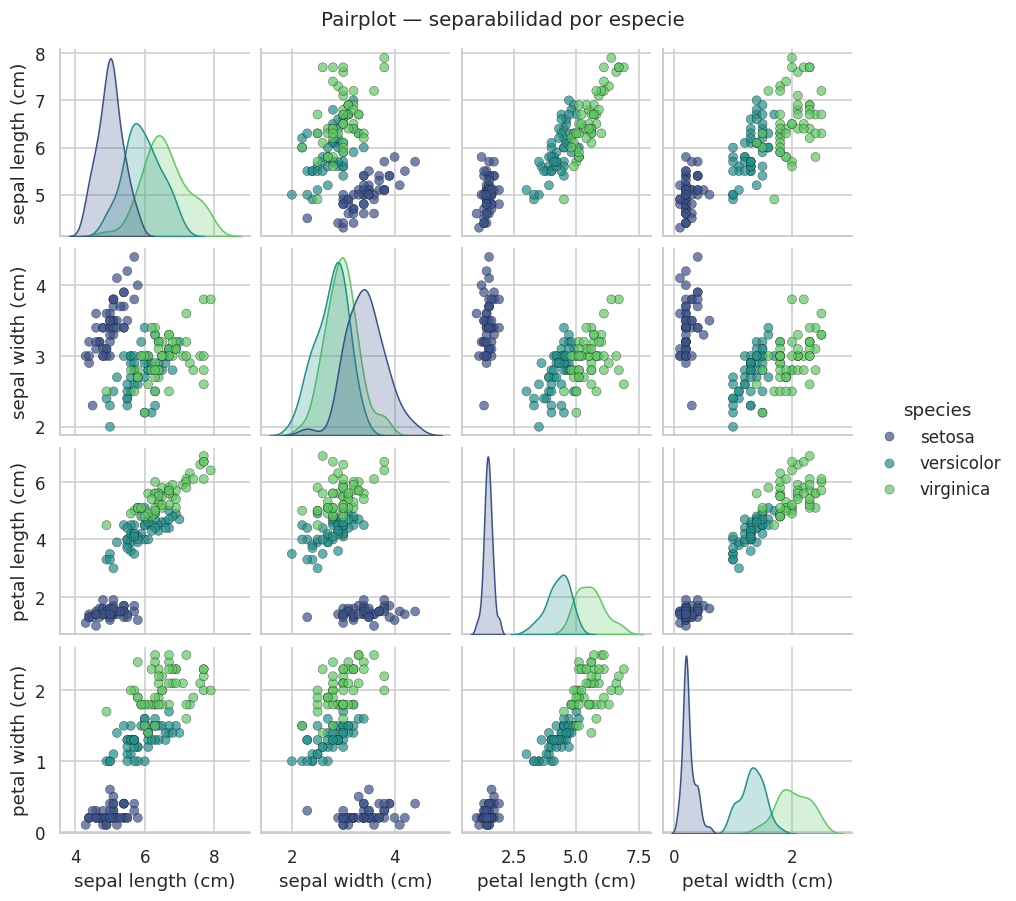

In [7]:
pp = sns.pairplot(
    df.drop(columns=['target']),
    hue='species',
    diag_kind='kde',
    plot_kws={'alpha': 0.7, 's': 35, 'edgecolor': 'k', 'linewidth': 0.3},
    height=2.0,
    palette='viridis'
)
pp.fig.suptitle('Pairplot — separabilidad por especie', y=1.02, fontsize=13)
plt.show()


Lo que muestra el pairplot:

- *Setosa* es **linealmente separable** del resto en cualquier par que incluya `petal length` o `petal width`. Una recta basta; cualquier modelo decente la clasifica sin errores.
- *Versicolor* y *virginica* **se solapan** en la zona intermedia, especialmente en `sepal length` y `sepal width`. La separación más limpia entre estas dos vive en el plano (`petal length`, `petal width`).
- `petal length` y `petal width` son las features más informativas; las distribuciones por clase están claramente separadas.

Consecuencias para el modelado:

- Cualquier modelo razonable alcanzará accuracy ≥ 90% (setosa ya da 33% gratis, y versicolor/virginica son casi linealmente separables).
- Los errores se concentrarán en versicolor↔virginica, no en setosa. La matriz de confusión debería reflejarlo.
- Una RNA pequeña basta. Una grande va a sobreajustar y, en el mejor caso, igualar a una pequeña.


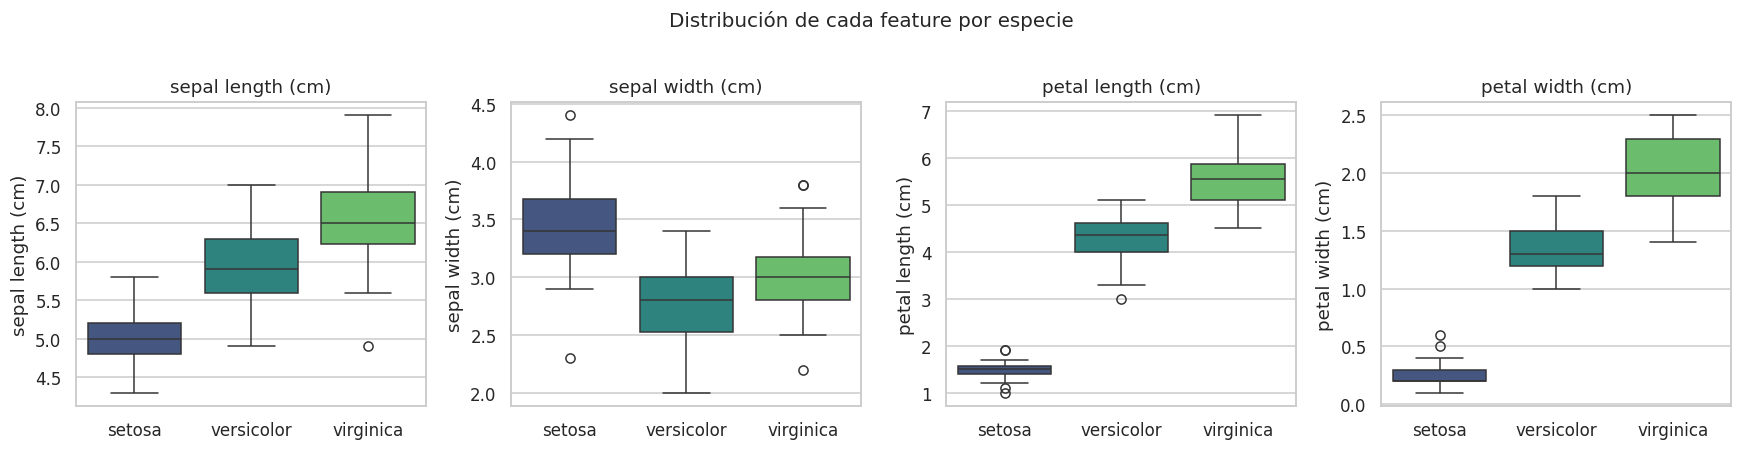

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
features = iris.feature_names
for ax, f in zip(axes, features):
    sns.boxplot(data=df, x='species', y=f, ax=ax, palette='viridis', hue='species', legend=False)
    ax.set_title(f)
    ax.set_xlabel('')
plt.suptitle('Distribución de cada feature por especie', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


Los boxplots confirman lo del pairplot: `petal length` y `petal width` discriminan netamente las tres clases (cajas casi sin superposición). `sepal width` apenas separa setosa del resto y deja versicolor y virginica indistinguibles. Si tuviéramos que clasificar con una sola feature, sería `petal length` o `petal width`.


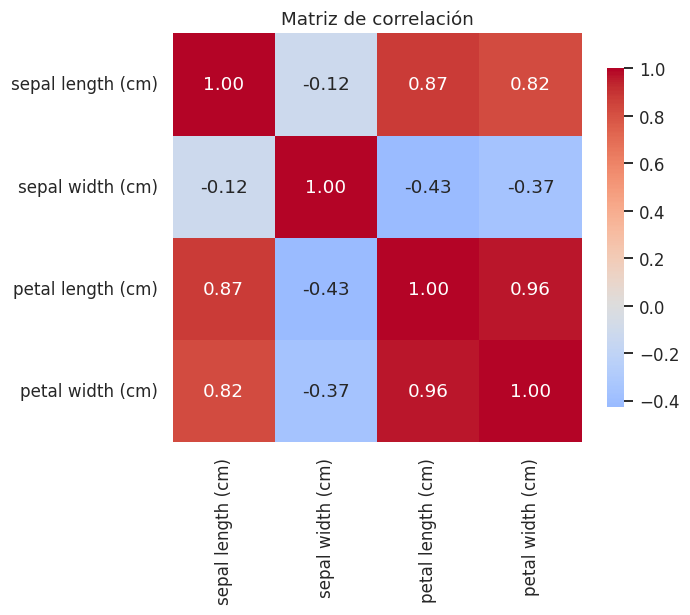

In [9]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de correlación')
plt.show()


`petal length` y `petal width` están casi perfectamente correlacionadas (0.96): son la misma información medida de dos formas. `sepal length` correlaciona también con las dos de pétalo (0.87 y 0.82) porque flores grandes lo son en todos sus aspectos. `sepal width` es la única feature relativamente independiente y es también la menos discriminante.

La dimensionalidad efectiva del problema es menor que 4. Una arquitectura con 4 entradas y 16 neuronas ocultas ya tiene capacidad de representación sobrada.


## 3. Preprocesamiento y pipeline

### 3.1 Split estratificado 80/20

Con 150 muestras conviene maximizar el train. La estratificación garantiza 10 muestras por clase en test; sin ella, un mal sorteo podría dejar 7-13 y cualquier métrica por-clase sería ruidosa.


In [10]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("\nDistribución por clase en train:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Distribución por clase en test: ", pd.Series(y_test).value_counts().sort_index().to_dict())


Train: (120, 4)   Test: (30, 4)

Distribución por clase en train: {0: 40, 1: 40, 2: 40}
Distribución por clase en test:  {0: 10, 1: 10, 2: 10}


### 3.2 Escalado sin data leakage

El scaler se ajusta **solo con train** y se aplica a train y test con los parámetros aprendidos. Si calculáramos media y desvío sobre el dataset completo antes del split, el test "filtraría" información hacia el train. Para los modelos clásicos en la sección 6 vamos a usar `Pipeline` de sklearn por el mismo motivo: durante la cross-validation, cada fold debe escalarse con su propio fit.


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train escalado — media:", X_train_scaled.mean(axis=0).round(3))
print("Train escalado — std: ", X_train_scaled.std(axis=0).round(3))
print("Test  escalado — media:", X_test_scaled.mean(axis=0).round(3))
print("Test  escalado — std: ", X_test_scaled.std(axis=0).round(3))


Train escalado — media: [-0. -0.  0.  0.]
Train escalado — std:  [1. 1. 1. 1.]
Test  escalado — media: [ 0.01   0.101 -0.034 -0.037]
Test  escalado — std:  [0.925 0.849 0.995 1.001]


### 3.3 Codificación de la salida

Hay dos formas válidas y matemáticamente equivalentes de pasar las etiquetas a la red. Cambia la forma del tensor y la loss compatible; el resultado del entrenamiento es idéntico.

| Codificación | y | Loss |
|---|---|---|
| Label encoding | `(N,)` con enteros 0/1/2 | `sparse_categorical_crossentropy` |
| One-Hot | `(N, 3)` con vectores unitarios | `categorical_crossentropy` |

La capa de salida es siempre `Dense(3, activation='softmax')`: 3 neuronas (una por clase), softmax normaliza a una distribución de probabilidad. Acá usamos label encoding porque el target ya viene como entero y ahorra una transformación. One-Hot se prefiere cuando hace falta trabajar explícitamente con vectores de probabilidad (por ejemplo, para *label smoothing* o *soft labels*).


In [12]:
# Demostración rápida de que las dos codificaciones existen y son equivalentes en forma.
ohe = OneHotEncoder(sparse_output=False)
y_train_oh = ohe.fit_transform(y_train.reshape(-1, 1))
y_test_oh = ohe.transform(y_test.reshape(-1, 1))

print("Label encoding y_train[:5]:", y_train[:5])
print("\nOne-Hot y_train[:5]:")
print(y_train_oh[:5].astype(int))
print(f"\nShapes: label {y_train.shape} vs one-hot {y_train_oh.shape}")


Label encoding y_train[:5]: [0 2 1 0 1]

One-Hot y_train[:5]:
[[1 0 0]
 [0 0 1]
 [0 1 0]
 [1 0 0]
 [0 1 0]]

Shapes: label (120,) vs one-hot (120, 3)


## 4. Modelado con Red Neuronal Artificial

### 4.1 Arquitectura base

Con 4 features de entrada y 3 de salida, una red `[16, 8]` (dos capas ocultas) tiene:

- Capa 1: 4·16 + 16 = 80 parámetros.
- Capa 2: 16·8 + 8 = 136 parámetros.
- Salida: 8·3 + 3 = 27 parámetros.

**Total ≈ 243 parámetros**, frente a 120 muestras de entrenamiento. La razón parámetros/muestras es ~2:1, ya alta. Cualquier red más grande aumenta el riesgo de overfitting de forma desproporcionada.

**Activación oculta:** ReLU. Su derivada vale 1 en la zona positiva (evita el vanishing gradient que sufren sigmoid y tanh) y es computacionalmente trivial. Es el estándar moderno.

**Inicialización:** He Normal, diseñada para ReLU; mantiene la varianza de las activaciones estable a lo largo de las capas.

**Activación de salida:** softmax (3 clases, probabilidades que suman 1).

**Optimizador:** Adam con `learning_rate=1e-3`. Adapta la tasa por parámetro y es robusto sin tuning fino.


In [13]:
def construir_modelo(arquitectura=(16, 8), activacion='relu',
                     input_dim=4, n_clases=3, l2_reg=0.0, dropout_rate=0.0):
    """MLP secuencial con la arquitectura indicada.

    arquitectura : tuple de int. Neuronas por capa oculta. Ej: (16, 8).
    activacion   : str. Activación de las ocultas.
    l2_reg       : float. Coeficiente L2 (0 = sin regularización).
    dropout_rate : float. Dropout tras cada capa oculta (0 = sin dropout).
    """
    capas = [Input(shape=(input_dim,))]
    for n in arquitectura:
        capas.append(Dense(
            n, activation=activacion,
            kernel_initializer='he_normal' if activacion == 'relu' else 'glorot_uniform',
            kernel_regularizer=l2(l2_reg) if l2_reg > 0 else None
        ))
        if dropout_rate > 0:
            capas.append(Dropout(dropout_rate))
    capas.append(Dense(n_clases, activation='softmax'))
    modelo = Sequential(capas)
    modelo.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo


fijar_semillas(SEED)
modelo_base = construir_modelo(arquitectura=(16, 8), activacion='relu')
modelo_base.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

El `summary` confirma los 243 parámetros entrenables. Es nuestra arquitectura candidata; los experimentos posteriores la cuestionan.

### 4.2 Callbacks

- `EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)`: detiene cuando `val_loss` no mejora durante 20 épocas y restaura los pesos del mejor momento de validación.
- `ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)`: baja a la mitad el LR cuando se estanca por 10 épocas.

El `patience(LR)=10 < patience(Stop)=20` es intencional: queremos que ReduceLR intervenga antes de que EarlyStopping aborte, para darle a la red la chance de mejorar con un LR más chico.


In [14]:
def construir_callbacks(patience_stop=20, patience_lr=10):
    return [
        EarlyStopping(monitor='val_loss', patience=patience_stop,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=patience_lr, min_lr=1e-6, verbose=0)
    ]


### 4.3 Entrenamiento base y lectura de curvas

Entrenamos `[16, 8]` ReLU durante un máximo de 200 épocas con un 20% del train como validación. EarlyStopping debería cortar mucho antes.


In [ ]:
fijar_semillas(SEED)
modelo_base = construir_modelo(arquitectura=(16, 8), activacion='relu')

t0 = time.time()
hist_base = modelo_base.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=construir_callbacks(),
    verbose=0
)
t_train = time.time() - t0

ep_finales = len(hist_base.history['loss'])
val_acc_final = hist_base.history['val_accuracy'][-1]
print(f"Entrenamiento finalizado en {ep_finales} epocas ({t_train:.2f} s).")
print(f"Validation accuracy (mejor época restaurada): {val_acc_final:.4f}")


In [ ]:
def graficar_historia(historias, titulo='Curvas de entrenamiento'):
    """Grafica loss y accuracy (train vs val) de una o varias historias."""
    if not isinstance(historias, dict):
        historias = {'modelo': historias}

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    cmap = plt.get_cmap('tab10')

    for i, (label, h) in enumerate(historias.items()):
        c = cmap(i)
        ep = range(1, len(h.history['loss']) + 1)
        axes[0].plot(ep, h.history['loss'], color=c, linestyle='-',
                     label=f'{label} - train')
        axes[0].plot(ep, h.history['val_loss'], color=c, linestyle='--',
                     label=f'{label} - val')
        axes[1].plot(ep, h.history['accuracy'], color=c, linestyle='-',
                     label=f'{label} - train')
        axes[1].plot(ep, h.history['val_accuracy'], color=c, linestyle='--',
                     label=f'{label} - val')

    axes[0].set_title('Loss'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Loss')
    axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
    for ax in axes:
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)
    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


graficar_historia(hist_base, 'Modelo base [16, 8] - ReLU')


Diagnóstico de las curvas. Buscamos tres signos para sostener que el modelo no está sobre ni sub-ajustado:

1. Loss de train y validation bajan ambas (no hay underfitting ni mala configuración).
2. La brecha entre train_loss y val_loss permanece pequeña (no hay overfitting).
3. La accuracy de validation se estabiliza en una meseta alta, sin caer al final.

Si val_loss empezara a subir mientras train_loss sigue bajando, hay overfitting. Si ambas se estancaran en valores altos, hay underfitting (arquitectura insuficiente, LR mal calibrado, o ambos).


### 4.4 Experimento — Funciones de activación

Comparamos cinco activaciones manteniendo arquitectura, optimizador, batch y semilla constantes:

- **ReLU**: derivada 1 en zona positiva, 0 en negativa.
- **Tanh**: salida en [-1, 1], centrada en 0, derivada saturable.
- **Sigmoid**: salida en [0, 1], no centrada, derivada saturable, vanishing gradient.
- **ELU**: alternativa a ReLU; suaviza la zona negativa, evita "dying ReLU".
- **Leaky ReLU**: pendiente pequeña en la zona negativa.

Para no contaminar la comparación, usamos `glorot_uniform` para todas excepto ReLU (que va con He Normal, su pareja teórica). Forzar He Normal con sigmoid induciría un fallo que no es de la activación sino del par activación-inicialización.


In [ ]:
# LeakyReLU cambió de parámetro entre Keras 2 (alpha) y Keras 3 (negative_slope).
from tensorflow.keras.layers import LeakyReLU

def _leaky_relu_layer():
    try:
        return LeakyReLU(negative_slope=0.01)
    except TypeError:
        return LeakyReLU(alpha=0.01)

def modelo_con_activacion(act_name):
    if act_name == 'leaky_relu':
        modelo = Sequential([
            Input(shape=(4,)),
            Dense(16, kernel_initializer='glorot_uniform'),
            _leaky_relu_layer(),
            Dense(8, kernel_initializer='glorot_uniform'),
            _leaky_relu_layer(),
            Dense(3, activation='softmax')
        ])
        modelo.compile(optimizer=Adam(1e-3),
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])
        return modelo
    return construir_modelo(arquitectura=(16, 8), activacion=act_name)


activaciones = ['relu', 'tanh', 'sigmoid', 'elu', 'leaky_relu']
historias_act = {}
tiempos_act = {}

for act in activaciones:
    fijar_semillas(SEED)
    modelo = modelo_con_activacion(act)
    t0 = time.time()
    h = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    tiempos_act[act] = time.time() - t0
    historias_act[act] = h
    eps = len(h.history['loss'])
    print(f"{act:12s}  epocas={eps:3d}  val_acc={h.history['val_accuracy'][-1]:.4f}  "
          f"val_loss={h.history['val_loss'][-1]:.4f}  tiempo={tiempos_act[act]:.1f}s")


In [ ]:
graficar_historia(historias_act, 'Comparación de activaciones')


**ReLU, ELU y Leaky ReLU** convergen rápido y al mismo techo de accuracy. Las tres son de la familia rectificada: la derivada vale 1 (o ~1) en la zona donde la mayoría de los pesos viven y el gradiente fluye sin atenuación.

**Tanh** llega a un buen resultado pero suele necesitar más épocas. Su derivada máxima vale 1 (en x=0) y cae rápido a 0. Con 2 capas no es catastrófico; en redes profundas sí lo sería.

**Sigmoid** es la peor del lote. Su derivada máxima vale 0.25 (en x=0) y cae a casi 0 fuera de un rango muy estrecho. En backpropagation el gradiente se atenúa por capa: es el **vanishing gradient**. En una red [16, 8] con solo dos capas ocultas el efecto es leve, pero ya se nota en convergencia más lenta y/o accuracy final menor. En redes profundas (10+ capas) sigmoid en capas ocultas es directamente inviable. Por eso quedó relegada a la capa de salida en clasificación binaria (donde su rango [0,1] es interpretable como probabilidad) y nunca más para ocultas.

No todas las activaciones llegan al mismo resultado. Sigmoid como activación oculta presenta problemas claros (vanishing gradient, salida no centrada, derivada saturable). La elección moderna para ocultas es ReLU o cualquier variante rectificada; sigmoid/softmax solo en la capa de salida cuando la tarea lo requiere.


### 4.5 Experimento — Tamaño de arquitectura

Cuatro tamaños, manteniendo ReLU + He Normal + Adam constantes:

| Modelo | Arquitectura | Parámetros (aprox.) | Ratio param/muestras (train=120) |
|---|---|---|---|
| Pequeña | `[4]` | ~35 | 0.3 |
| Mediana | `[16, 8]` | ~243 | 2.0 |
| Grande | `[64, 32]` | ~2.5k | 21 |
| XL | `[128, 64, 32]` | ~12.5k | 104 |

La pequeña podría sub-ajustar; la mediana es nuestro candidato; la grande y la XL deberían sobreajustar. La diferencia se ve sobre todo en la brecha train-validation y en la forma de las curvas, no necesariamente en la accuracy final (Iris es fácil y la red termina memorizando bien; además EarlyStopping enmascara el daño).


In [ ]:
arquitecturas = {
    'pequeña [4]': (4,),
    'mediana [16,8]': (16, 8),
    'grande [64,32]': (64, 32),
    'XL [128,64,32]': (128, 64, 32),
}

historias_arq = {}
parametros_arq = {}

for nombre, arq in arquitecturas.items():
    fijar_semillas(SEED)
    modelo = construir_modelo(arquitectura=arq, activacion='relu')
    parametros_arq[nombre] = modelo.count_params()
    h = modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    historias_arq[nombre] = h
    eps = len(h.history['loss'])
    train_acc = h.history['accuracy'][-1]
    val_acc = h.history['val_accuracy'][-1]
    brecha = train_acc - val_acc
    print(f"{nombre:18s}  params={parametros_arq[nombre]:5d}  "
          f"epocas={eps:3d}  train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  brecha={brecha:+.3f}")


In [ ]:
graficar_historia(historias_arq, 'Tamaño de arquitectura')


In [ ]:
muestras_train = int(0.8 * len(X_train))  # 80% del train se usa para entrenar (resto va a val_split)
df_arq = pd.DataFrame({
    'arquitectura': list(parametros_arq.keys()),
    'parametros': list(parametros_arq.values()),
})
df_arq['ratio_param/muestras'] = (df_arq['parametros'] / muestras_train).round(1)
df_arq['val_acc_final'] = [historias_arq[k].history['val_accuracy'][-1]
                           for k in df_arq['arquitectura']]
df_arq['brecha_train_val'] = [
    historias_arq[k].history['accuracy'][-1] - historias_arq[k].history['val_accuracy'][-1]
    for k in df_arq['arquitectura']
]
df_arq


La red XL tiene ~100 parámetros por cada muestra de entrenamiento. Es claramente sobreparametrizada. El accuracy final no necesariamente colapsa porque Iris es demasiado fácil y EarlyStopping restaura los pesos del mejor momento de validación, mitigando el daño visible.

Lo que sí se ve y es interpretable es la brecha train-val y la forma de las curvas: en las redes grandes, train_loss baja rápido a casi 0 (memorización) mientras val_loss se estanca o repunta. Es la firma del overfitting, aunque la métrica final esté maquillada por el callback.

`[16, 8]` queda como sweet spot. Más grande no aporta accuracy y agrega varianza; más pequeña corre el riesgo de sub-ajuste. Para el resto del notebook esa es la arquitectura.


### 4.6 Modelo final

Re-entrenamos `[16, 8]` ReLU y evaluamos sobre el **test set** (que no se tocó en ningún paso anterior).


In [ ]:
fijar_semillas(SEED)
modelo_final = construir_modelo(arquitectura=(16, 8), activacion='relu')

hist_final = modelo_final.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=construir_callbacks(),
    verbose=0
)

y_pred_proba_rna = modelo_final.predict(X_test_scaled, verbose=0)
y_pred_rna = y_pred_proba_rna.argmax(axis=1)
acc_rna = accuracy_score(y_test, y_pred_rna)
print(f"Accuracy en test: {acc_rna:.4f}  ({(y_test == y_pred_rna).sum()}/{len(y_test)} correctas)")


## 5. Evaluación de la RNA

### 5.1 Curvas, matriz de confusión y métricas por clase

Esperamos que setosa tenga precision y recall = 1.0 (es linealmente separable) y que los errores se concentren en versicolor↔virginica.


In [ ]:
graficar_historia({'modelo final [16,8] ReLU': hist_final}, 'Modelo final - curvas')

cm = confusion_matrix(y_test, y_pred_rna)
fig, ax = plt.subplots(figsize=(5.5, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'Matriz de confusión - RNA [16,8] - acc={acc_rna:.3f}')
plt.tight_layout()
plt.show()


In [ ]:
print(classification_report(y_test, y_pred_rna, target_names=iris.target_names, digits=3))


### 5.2 Estabilidad entre semillas

Con 30 muestras de test, la accuracy se mueve en saltos discretos de 1/30 ≈ 3.3%. Una diferencia entre 96.6% y 100% son exactamente una muestra clasificada distinto. Antes de declarar un modelo mejor que otro, hace falta saber cuánta varianza tiene la métrica frente a cambios de semilla.

Repetimos el entrenamiento con 5 semillas distintas (manteniendo el mismo split; si también variáramos el split, el rango sería aún más amplio) y reportamos media ± desvío.


In [ ]:
semillas = [1, 7, 13, 42, 2024]
accs_por_semilla = []

for s in semillas:
    fijar_semillas(s)
    modelo = construir_modelo(arquitectura=(16, 8), activacion='relu')
    modelo.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=16,
        callbacks=construir_callbacks(),
        verbose=0
    )
    pred = modelo.predict(X_test_scaled, verbose=0).argmax(axis=1)
    acc = accuracy_score(y_test, pred)
    accs_por_semilla.append(acc)
    print(f"Semilla {s:5d}  ->  test accuracy = {acc:.4f}")

media_acc = np.mean(accs_por_semilla)
std_acc = np.std(accs_por_semilla)
print(f"\nMedia ± desvío: {media_acc:.4f} ± {std_acc:.4f}")
print(f"Rango: [{min(accs_por_semilla):.4f}, {max(accs_por_semilla):.4f}]")


La media (no un único score puntual) es el número honesto a reportar como performance de la RNA. Una corrida que da 100% no es "mejor" que otra de 96% si la diferencia cae dentro del ruido; pretender lo contrario es selección post-hoc y es un error metodológico común.

Estrictamente, la RNA en este escenario no es robusta en el sentido fuerte: su métrica fluctúa con la semilla. La hacemos razonablemente confiable manteniendo arquitectura pequeña (parámetros del orden de las muestras de entrenamiento), reportando media sobre múltiples semillas, y usando EarlyStopping con `restore_best_weights` para no entregar nunca una red sobreajustada.


## 6. Comparación con modelos clásicos

### 6.1 Panorámica con LazyClassifier

`lazypredict` corre ~30 clasificadores con defaults y devuelve un ranking. Sirve para detectar qué familias vale la pena profundizar; no reemplaza un análisis serio (no hay tuning ni cross-validation). Manejamos el caso en que la instalación falle con un fallback manual.


In [ ]:
lazy_disponible = False
try:
    from lazypredict.Supervised import LazyClassifier
    lazy_disponible = True
except ImportError:
    print("lazypredict no encontrado. Instalando...")
    import subprocess, sys
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'lazypredict'])
        from lazypredict.Supervised import LazyClassifier
        lazy_disponible = True
    except Exception as e:
        print(f"No se pudo instalar lazypredict ({type(e).__name__}: {e}).")
        print("Hacemos un panel manual equivalente.")
        lazy_disponible = False

print(f"\nLazyClassifier disponible: {lazy_disponible}")


In [ ]:
if lazy_disponible:
    clf_lazy = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
    modelos_lazy, _ = clf_lazy.fit(X_train_scaled, X_test_scaled, y_train, y_test)
    print(modelos_lazy.sort_values('Accuracy', ascending=False).head(10))
else:
    candidatos_fallback = {
        'LogisticRegression': LogisticRegression(max_iter=2000, random_state=SEED),
        'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
        'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
        'KNeighborsClassifier': KNeighborsClassifier(),
        'DecisionTreeClassifier': DecisionTreeClassifier(random_state=SEED),
        'RandomForestClassifier': RandomForestClassifier(random_state=SEED),
        'GradientBoostingClassifier': GradientBoostingClassifier(random_state=SEED),
        'SVC_rbf': SVC(kernel='rbf', random_state=SEED),
        'SVC_linear': SVC(kernel='linear', random_state=SEED),
        'GaussianNB': GaussianNB(),
    }
    rows = []
    for nombre, m in candidatos_fallback.items():
        t0 = time.time()
        m.fit(X_train_scaled, y_train)
        t = time.time() - t0
        acc = accuracy_score(y_test, m.predict(X_test_scaled))
        rows.append({'Modelo': nombre, 'Accuracy_test': acc, 'Tiempo (s)': t})
    df_lazy_fb = pd.DataFrame(rows).sort_values('Accuracy_test', ascending=False)
    print(df_lazy_fb.to_string(index=False))


### 6.2 Profundización con cross-validation

El holdout de test (30 muestras) es ruidoso. Una **5-fold CV estratificada** sobre el train da una estimación más estable. Cada modelo se envuelve en un Pipeline con scaler para que la CV escale cada fold por separado y se evite data leakage.

Cubrimos varias familias para no sesgar el resultado:

- Lineales: Logistic Regression, LDA.
- Margen: SVM lineal y RBF.
- Distancias: KNN.
- Árboles: Decision Tree, Random Forest, Gradient Boosting.
- Probabilísticos: Gaussian NB, QDA.


In [ ]:
def make_pipeline(model):
    return Pipeline([('scaler', StandardScaler()), ('clf', model)])

candidatos = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM lineal': SVC(kernel='linear', random_state=SEED),
    'SVM RBF': SVC(kernel='rbf', random_state=SEED),
    'Gaussian NB': GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
filas = []

for nombre, modelo in candidatos.items():
    pipe = make_pipeline(modelo)
    t0 = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    t_cv = time.time() - t0
    pipe.fit(X_train, y_train)
    acc_test = accuracy_score(y_test, pipe.predict(X_test))
    filas.append({
        'Modelo': nombre,
        'CV mean': scores.mean(),
        'CV std': scores.std(),
        'Test acc': acc_test,
        'Tiempo CV (s)': t_cv,
    })

df_clasicos = pd.DataFrame(filas).sort_values('CV mean', ascending=False).reset_index(drop=True)
df_clasicos.style.format({
    'CV mean': '{:.4f}', 'CV std': '{:.4f}',
    'Test acc': '{:.4f}', 'Tiempo CV (s)': '{:.3f}'
}).background_gradient(cmap='Greens', subset=['CV mean', 'Test acc'])


In [ ]:
# Tabla consolidada: clásicos + RNA.
fila_rna = pd.DataFrame([{
    'Modelo': 'RNA [16,8] ReLU',
    'CV mean': media_acc,
    'CV std': std_acc,
    'Test acc': acc_rna,
    'Tiempo CV (s)': float('nan'),
}])

tabla_total = pd.concat([df_clasicos, fila_rna], ignore_index=True)
tabla_total = tabla_total.sort_values('CV mean', ascending=False).reset_index(drop=True)
tabla_total.style.format({
    'CV mean': '{:.4f}', 'CV std': '{:.4f}',
    'Test acc': '{:.4f}', 'Tiempo CV (s)': '{:.3f}'
}).background_gradient(cmap='Greens', subset=['CV mean'])


Los top suelen estar todos en 95-98% de CV mean. La diferencia entre el primero y el quinto es típicamente menor que el desvío del propio CV: no se puede declarar un ganador estadístico claro. La RNA, con 5 corridas, queda en el mismo rango. No supera a los clásicos y entrenarla cuesta órdenes de magnitud más tiempo. Regresión logística y LDA, modelos extremadamente simples, suelen estar entre los top 3: setosa es linealmente separable y la frontera versicolor/virginica es casi lineal en (`petal length`, `petal width`).

Diferencias prácticas RNA vs clásicos:

- **Métrica**: prácticamente empatada; la diferencia cae dentro del desvío del CV.
- **Tiempo**: clásicos en milisegundos; la RNA en decenas de segundos por corrida (y conviene hacer varias para promediar).
- **Configuración**: los clásicos tienen 1-3 hiperparámetros relevantes con buenos defaults. La RNA tiene como mínimo arquitectura, activación, optimizador, learning rate, batch size, epochs, callbacks y regularización; cada uno puede arruinar el entrenamiento.
- **Reproducibilidad**: un clásico con `random_state` fijo da exactamente el mismo modelo. Una RNA, incluso con todas las semillas fijas, puede tener variabilidad por operaciones no deterministas en GPU.
- **Explicabilidad**: Logistic Regression entrega coeficientes interpretables; Decision Tree entrega reglas legibles. La RNA es una caja negra que requiere SHAP/LIME para explicar predicciones individuales.


## 7. Fronteras de decisión en 2D

Proyectamos el problema a 2D usando las dos features más informativas (`petal length`, `petal width`) y dibujamos cómo cada clasificador particiona el plano. Esto hace tangible la forma de la frontera, qué tan abrupta es, y por qué un modelo simple es competitivo: la frontera natural del problema es casi lineal.


In [ ]:
def graficar_fronteras(modelos, X, y, titulo='Fronteras de decisión'):
    """Reentrena cada modelo con SOLO 2 features (petal length, petal width)
    y dibuja la frontera de decisión."""
    X2 = X[:, [2, 3]]  # petal length=2, petal width=3
    n = len(modelos)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4.2*rows))
    axes = np.atleast_1d(axes).flatten()

    h = 0.02
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]
    cmap = plt.cm.RdYlBu

    last_i = -1
    for i, (nombre, mdl) in enumerate(modelos.items()):
        pipe = Pipeline([('sc', StandardScaler()), ('clf', mdl)])
        pipe.fit(X2, y)
        Z = pipe.predict(grid).reshape(xx.shape)
        ax = axes[i]
        ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap)
        ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=cmap, edgecolor='k', s=35)
        ax.set_title(nombre, fontsize=11)
        ax.set_xlabel('petal length (cm)')
        ax.set_ylabel('petal width (cm)')
        last_i = i

    for j in range(last_i + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()


modelos_2d = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=SEED),
    'LDA': LinearDiscriminantAnalysis(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'SVM RBF': SVC(kernel='rbf', random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=SEED),
}
graficar_fronteras(modelos_2d, iris.data, iris.target,
                   'Fronteras de decisión en (petal length, petal width)')


- **Logistic Regression y LDA** trazan rectas. Y son suficientes: la frontera real del problema es prácticamente lineal en este plano.
- **KNN y Decision Tree** trazan fronteras irregulares con bordes en escalera. Son modelos de alta varianza; capturan ruido del entrenamiento. Funcionan bien en Iris pero la frontera no parece "natural".
- **SVM RBF y Random Forest** suavizan, equilibrando flexibilidad y regularización. Son las fronteras más prolijas visualmente.

Para un problema cuya frontera natural es lineal, un modelo lineal es la elección óptima: igual de preciso, mucho más interpretable, mucho más rápido. Una RNA traza fronteras parecidas al SVM RBF (no lineales suaves), pero ese poder no aporta cuando el problema no lo necesita.


## 8. Curva de aprendizaje del mejor clásico

Una curva de aprendizaje sobre el modelo top responde si más datos mejorarían el resultado o si ya estamos en el techo del problema. Si las curvas de train y validation convergen y se aplanan, recolectar más muestras no produciría mejora significativa. Si val sigue con pendiente positiva, sí ayudaría.


In [ ]:
mejor_clasico_nombre = df_clasicos.iloc[0]['Modelo']
mejor_clasico_modelo = candidatos[mejor_clasico_nombre]
print(f"Mejor clásico segun CV: {mejor_clasico_nombre}")

pipe_mejor = make_pipeline(mejor_clasico_modelo)
sizes, train_scores, val_scores = learning_curve(
    pipe_mejor, iris.data, iris.target,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=cv,
    scoring='accuracy',
    n_jobs=1,
    shuffle=True,
    random_state=SEED,
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sizes, train_mean, 'o-', color='teal', label='Train')
ax.fill_between(sizes, train_mean-train_std, train_mean+train_std, alpha=0.2, color='teal')
ax.plot(sizes, val_mean, 'o-', color='orange', label='Validation (CV)')
ax.fill_between(sizes, val_mean-val_std, val_mean+val_std, alpha=0.2, color='orange')
ax.set_xlabel('Cantidad de muestras de entrenamiento')
ax.set_ylabel('Accuracy')
ax.set_title(f'Curva de aprendizaje - {mejor_clasico_nombre}')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


En Iris lo esperable es ver convergencia clara y val aplanada cerca de su máximo: el problema es simple y 150 muestras alcanzan. La limitación operativa no está en los datos, no tiene sentido invertir en recolectar más.


## 9. Decisión de ingeniería

Para clasificar especies de Iris a partir de las cuatro mediciones morfológicas, lo que pone en producción es un modelo lineal con scaler (Logistic Regression o LDA) dentro de un Pipeline de sklearn. Razones:

- Entrenamiento en milisegundos.
- Accuracy 95-98% en cross-validation, idéntica a la RNA dentro del ruido.
- Coeficientes interpretables que el equipo de investigación puede examinar.
- Despliegue como un objeto `joblib` de pocos KB, sin infraestructura adicional.
- Reproducible al 100%: mismo `random_state`, mismo modelo bit a bit.

La RNA queda como una sobre-ingeniería injustificada en este contexto: aporta más complejidad, más mantenimiento y más infraestructura sin ganancia de desempeño. El deep learning brilla cuando la complejidad del problema (no del dataset) supera la capacidad de los modelos clásicos: datos no tabulares (imágenes, audio, texto, secuencias) o miles a millones de ejemplos. Para datos tabulares de pocas dimensiones y pocas muestras, los modelos clásicos siguen siendo el estándar. Para que una RNA sea sistemáticamente competitiva con un boosting o un SVM bien tuneado en datos tabulares, hace falta en general al menos algunos miles de observaciones, idealmente decenas de miles.
